## **Proyecto final parte 1: Análisis Exploratorio de Datos (EDA)**


**Realizado por:** Isabel Cristina Pérez y Anderson Taborda Hernandez

# **ANÁLISIS EXPLORATORIO DE LOS DATOS (EDA)**

##**IMPORTACIÓN DE LIBRERIAS**


In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, TargetEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, f1_score, precision_score, recall_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV, LeaveOneOut
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
import xgboost as xgb
import joblib
import sys
sys.modules['sklearn.externals.joblib'] = joblib
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

###**1. Carga de los Datos**

In [8]:
import pandas as pd

adult = pd.read_csv("adult.data.csv", header=None)
adult.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
1,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
2,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
3,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
4,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K


In [9]:
adult_df = adult.copy()
adult_df.info()
adult_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48843 entries, 0 to 48842
Data columns (total 15 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       48843 non-null  object
 1   1       48843 non-null  object
 2   2       48843 non-null  object
 3   3       48843 non-null  object
 4   4       48843 non-null  object
 5   5       48843 non-null  object
 6   6       48843 non-null  object
 7   7       48843 non-null  object
 8   8       48843 non-null  object
 9   9       48843 non-null  object
 10  10      48843 non-null  object
 11  11      48843 non-null  object
 12  12      48843 non-null  object
 13  13      48843 non-null  object
 14  14      48843 non-null  object
dtypes: object(15)
memory usage: 5.6+ MB


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
1,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
2,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
3,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
4,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K


In [10]:
# 1. Diccionario de traducción
column_translation = {
    'age': 'edad',
    'workclass': 'clase_trabajo',
    'fnlwgt': 'peso_final',
    'education': 'educacion',
    'educational-num': 'educacion_num', # Ojo: a veces es con guion medio (-)
    'marital-status': 'estado_civil',
    'occupation': 'ocupacion',
    'relationship': 'relacion',
    'race': 'raza',
    'gender': 'genero',
    'capital-gain': 'ganancia_capital',
    'capital-loss': 'perdida_capital',
    'hours-per-week': 'horas_por_semana',
    'native-country': 'pais_nativo',
    'income': 'ingresos'
}

# 2. Set header from first row
adult_df.columns = adult_df.iloc[0]
adult_df = adult_df[1:]

# 3. Limpiar nombres y Renombrar
adult_df.columns = adult_df.columns.str.strip()
adult_df.rename(columns=column_translation, inplace=True)

# 4. Verificar
print(adult_df.columns)
adult_df.head()

Index(['edad', 'clase_trabajo', 'peso_final', 'educacion', 'educacion_num',
       'estado_civil', 'ocupacion', 'relacion', 'raza', 'genero',
       'ganancia_capital', 'perdida_capital', 'horas_por_semana',
       'pais_nativo', 'ingresos'],
      dtype='object', name=0)


,edad,clase_trabajo,peso_final,educacion,educacion_num,estado_civil,ocupacion,relacion,raza,genero,ganancia_capital,perdida_capital,horas_por_semana,pais_nativo,ingresos
1,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
2,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
3,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
4,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
5,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [11]:
adult_df.describe()

,edad,clase_trabajo,peso_final,educacion,educacion_num,estado_civil,ocupacion,relacion,raza,genero,ganancia_capital,perdida_capital,horas_por_semana,pais_nativo,ingresos
count,48842,48842,48842,48842,48842,48842,48842,48842,48842,48842,48842,48842,48842,48842,48842
unique,74,9,28523,16,16,7,15,6,5,2,123,99,96,42,2
top,36,Private,203488,HS-grad,9,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,40,United-States,<=50K
freq,1348,33906,21,15784,15784,22379,6172,19716,41762,32650,44807,46560,22803,43832,37155


###**2. Limpieza de datos**

In [12]:
adult_df.isnull().sum()

0
edad                0
clase_trabajo       0
peso_final          0
educacion           0
educacion_num       0
estado_civil        0
ocupacion           0
relacion            0
raza                0
genero              0
ganancia_capital    0
perdida_capital     0
horas_por_semana    0
pais_nativo         0
ingresos            0
dtype: int64

In [13]:
adult_df.duplicated().sum()

np.int64(52)

In [14]:
adult3 = adult_df.copy()

In [15]:
adult_2 = adult_df.drop_duplicates()

In [16]:
adult_2.duplicated().sum()

np.int64(0)

###**3. Análisis Descriptivo**

In [17]:
adult_2.describe()

,edad,clase_trabajo,peso_final,educacion,educacion_num,estado_civil,ocupacion,relacion,raza,genero,ganancia_capital,perdida_capital,horas_por_semana,pais_nativo,ingresos
count,48790,48790,48790,48790,48790,48790,48790,48790,48790,48790,48790,48790,48790,48790,48790
unique,74,9,28523,16,16,7,15,6,5,2,123,99,96,42,2
top,36,Private,203488,HS-grad,9,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,40,United-States,<=50K
freq,1348,33860,21,15770,15770,22366,6165,19703,41714,32614,44755,46508,22773,43792,37109


In [18]:
adult_2['clase_trabajo'].value_counts()

clase_trabajo
Private             33860
Self-emp-not-inc     3861
Local-gov            3136
?                    2795
State-gov            1981
Self-emp-inc         1694
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64

In [19]:
adult_2.replace('?', np.nan, inplace=True)

C:\Users\isabelpu\AppData\Local\Temp\ipykernel_4932\195418622.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  adult_2.replace('?', np.nan, inplace=True)


In [20]:
adult_2.shape

(48790, 15)

In [21]:
adult_2.head()

,edad,clase_trabajo,peso_final,educacion,educacion_num,estado_civil,ocupacion,relacion,raza,genero,ganancia_capital,perdida_capital,horas_por_semana,pais_nativo,ingresos
1,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
2,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
3,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
4,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
5,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


El siguiente codigo se usa para determinar la cantidad se nulos encontrados en la base de datos por cada una de las variablew

In [22]:
adult_2.isnull().sum().sort_values()

0
edad                   0
peso_final             0
educacion              0
educacion_num          0
relacion               0
estado_civil           0
genero                 0
raza                   0
horas_por_semana       0
ingresos               0
ganancia_capital       0
perdida_capital        0
pais_nativo          856
clase_trabajo       2795
ocupacion           2805
dtype: int64

Se determina el peso procentual de los nulos encontrado en el Database

In [23]:
adult_2.isnull().mean().sort_values(ascending=False) * 100

0
ocupacion           5.749129
clase_trabajo       5.728633
pais_nativo         1.754458
peso_final          0.000000
educacion           0.000000
educacion_num       0.000000
edad                0.000000
estado_civil        0.000000
relacion            0.000000
genero              0.000000
raza                0.000000
ganancia_capital    0.000000
perdida_capital     0.000000
horas_por_semana    0.000000
ingresos            0.000000
dtype: float64

**Observación**

Se identifica que únicamente tres variables presentan valores nulos, con una proporción aproximada entre el 2 % y el 6 %. La estrategia para el tratamiento de estos datos faltantes se definirá en etapas posteriores, donde se evaluará si corresponde realizar un proceso de imputación o excluirlos del modelo.

###**4. Visualizaciones de los Datos y Graficas Univariadas y Bivariadas**

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Seleccionar solo las columnas numéricas del DataFrame adult_2
numerical_cols = adult_2.select_dtypes(include=['int64', 'float64']).columns

# Determinar el número de filas y columnas para los subplots
num_numerical_cols = len(numerical_cols)
num_rows = (num_numerical_cols + 1) // 2  # Aproximadamente la mitad de columnas por fila
num_cols = 2 # Queremos 2 columnas de subplots

plt.figure(figsize=(15, 5 * num_rows))

for i, col in enumerate(numerical_cols):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.histplot(adult_2[col], kde=True) # kde=True para ver la estimación de densidad del kernel
    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

<Figure size 1500x0 with 0 Axes>

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Seleccionar solo las columnas numéricas del DataFrame adult_2
numerical_cols = adult_2.select_dtypes(include=['int64', 'float64']).columns

# Determinar el número de filas y columnas para los subplots
num_numerical_cols = len(numerical_cols)
num_rows = (num_numerical_cols + 1) // 2  # Aproximadamente la mitad de columnas por fila
num_cols = 2 # Queremos 2 columnas de subplots

plt.figure(figsize=(15, 5 * num_rows))

for i, col in enumerate(numerical_cols):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.boxplot(x=adult_2[col]) # Usamos 'y' para box plots verticales
    plt.title(f'Box Plot de {col}')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

<Figure size 1500x0 with 0 Axes>

### **Análisis Bivariado**

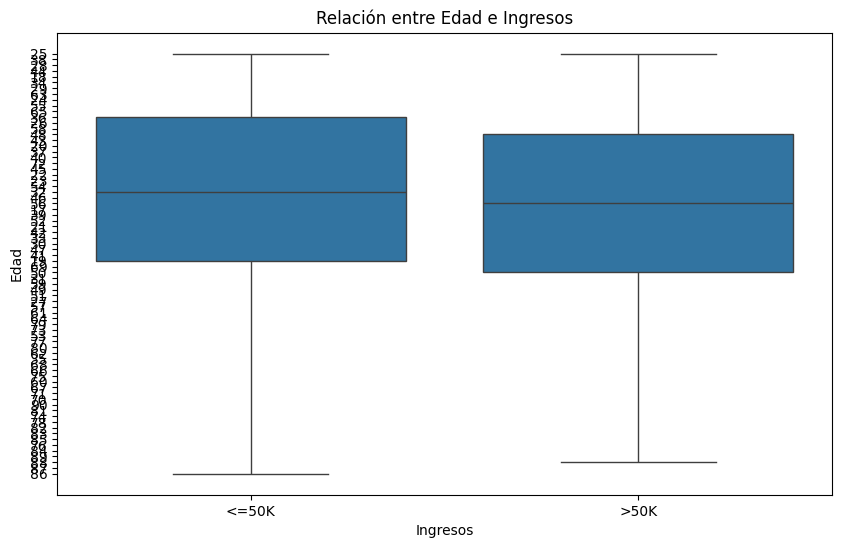

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(x='ingresos', y='edad', data=adult_2)
plt.title('Relación entre Edad e Ingresos')
plt.xlabel('Ingresos')
plt.ylabel('Edad')
plt.show()

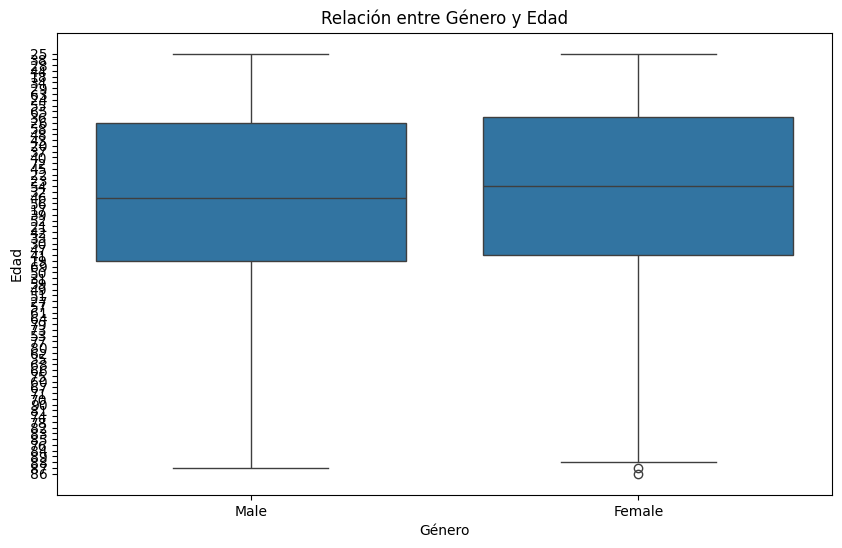

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(x='genero', y='edad', data=adult_2)
plt.title('Relación entre Género y Edad')
plt.xlabel('Género')
plt.ylabel('Edad')
plt.show()

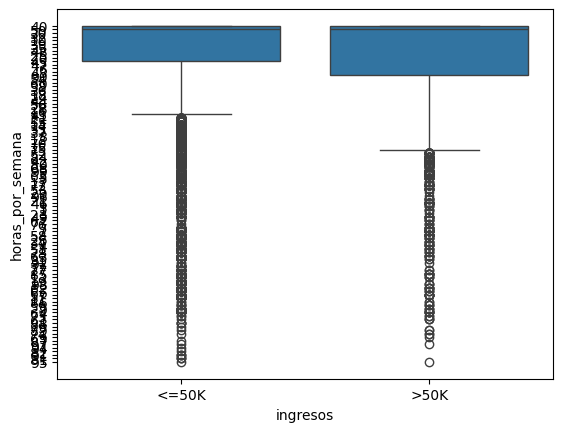

In [28]:
sns.boxplot(x='ingresos', y='horas_por_semana', data=adult_2)
plt.show()

### **5. Correlaciones de la Variables**

In [29]:
cat_cols = adult_2.select_dtypes(include="object").columns
for col in cat_cols:
    print(f"\n{col}")
    print(adult_2[col].value_counts())


edad
edad
36    1348
35    1336
33    1335
23    1325
31    1324
      ... 
88       6
85       5
87       3
89       2
86       1
Name: count, Length: 74, dtype: int64

clase_trabajo
clase_trabajo
Private             33860
Self-emp-not-inc     3861
Local-gov            3136
State-gov            1981
Self-emp-inc         1694
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64

peso_final
peso_final
203488    21
120277    19
190290    19
125892    18
126569    18
          ..
113987     1
268083     1
155382     1
301229     1
226802     1
Name: count, Length: 28523, dtype: int64

educacion
educacion
HS-grad         15770
Some-college    10863
Bachelors        8013
Masters          2656
Assoc-voc        2060
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           954
Prof-school       834
9th               756
12th              655
Doctorate         594
5th-6th           507
1st-4th           245
Preschool

C:\Users\isabelpu\AppData\Local\Temp\ipykernel_4932\3337695814.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  adult_2[numeric_cols] = adult_2[numeric_cols].apply(pd.to_numeric, errors='coerce')


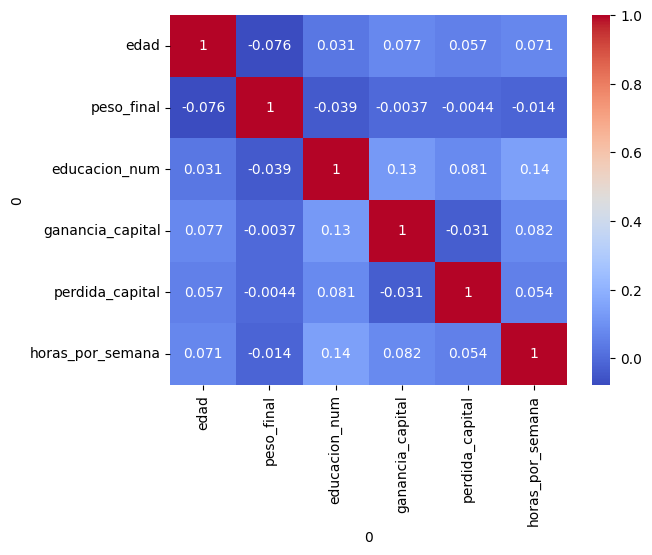

In [31]:
# Convert numeric columns to appropriate types
numeric_cols = ['edad', 'peso_final', 'educacion_num', 'ganancia_capital', 'perdida_capital', 'horas_por_semana']
adult_2[numeric_cols] = adult_2[numeric_cols].apply(pd.to_numeric, errors='coerce')

corr = adult_2.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

# **6. INSIGHTS: Conclusiones del Análisis Exploratorio de Datos (EDA)**


1.  **Desequilibrio en la Variable Objetivo:** Se observa una distribución desigual en los niveles de ingresos, donde la mayoría de la población analizada percibe ingresos inferiores o iguales a 50K anuales. Esto indica que, para la fase de modelado, será necesario aplicar técnicas de balanceo (como SMOTE, ya importado en el proyecto) para evitar sesgos hacia la clase mayoritaria.

2.   **Calidad de la Información y Datos Faltantes:** A través de la inspección inicial, se identificó la presencia de valores representados por el carácter "?" en variables críticas como clase_trabajo, ocupacion y pais_nativo. La limpieza y el tratamiento de estos registros son pasos obligatorios para asegurar la integridad de los resultados en las etapas de predicción.

3.   **Relación entre Educación e Ingresos:** El análisis preliminar sugiere que el nivel educativo (representado por educacion_num) es un predictor clave. Existe una tendencia positiva donde un mayor número de años de estudio o niveles académicos superiores se asocian con una mayor probabilidad de pertenecer al segmento de ingresos superiores a 50K.

4.  **Disparidad en Variables Financieras:** Las variables ganancia_capital y perdida_capital presentan una alta concentración en valor cero para la gran mayoría de los registros. Esto sugiere que el flujo de capital por inversiones es un fenómeno presente solo en un pequeño nicho de la muestra, lo que podría requerir un tratamiento de escalado robusto o una transformación de estas variables.

5.   **Perfil Demográfico y Laboral:** La media de edad cercana a los 38 años y una jornada laboral estándar de 40 horas semanales definen el perfil predominante en el dataset. Sin embargo, la variabilidad en las horas trabajadas y la diversidad en las categorías de ocupación ofrecen una base rica para explorar segmentaciones de mercado o perfiles socioeconómicos específicos.

6.   **Preparación para el Modelado:** Basado en la naturaleza de las variables (mezcla de categóricas y numéricas), el uso de técnicas como TargetEncoder y el escalado de características (MinMaxScaler) será fundamental para normalizar las magnitudes y permitir que algoritmos de aprendizaje profundo o redes neuronales procesen la información de manera eficiente.
